In [1]:
import json
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error
import optuna
from optuna.samplers import TPESampler
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [25]:
# ==================== PyTorch LSTM版本 ====================
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error


class LSTMTrainerPyTorch:
    """
    LSTM模型训练类 - PyTorch版本
    
    参数:
        seq_len: 时间序列长度 (默认7)
        n_features: 特征数量 (默认15)
        hidden_dim: LSTM隐藏层维度 (默认128)
        num_layers: LSTM层数 (默认2)
        bidirectional: 是否使用双向LSTM (默认True)
        dropout: Dropout比例 (默认0.1)
        learning_rate: 学习率 (默认0.001)
    """
    
    def __init__(self, seq_len=7, n_features=15, hidden_dim=128, num_layers=2,
                 bidirectional=True, dropout=0.1, learning_rate=0.01):
        self.seq_len = seq_len
        self.n_features = n_features
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        self.dropout = dropout
        self.learning_rate = learning_rate
        
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = None
        self.scaler_X = StandardScaler()
        self.scaler_y = StandardScaler()
        self.train_losses = []
        self.val_losses = []
        self.train_maes = []
        self.val_maes = []
        
        print(f"初始化PyTorch LSTM模型:")
        print(f"  设备: {self.device}")
        print(f"  输入形状: ({seq_len}, {n_features})")
        print(f"  隐藏维度: {hidden_dim}, LSTM层数: {num_layers}")
        print(f"  双向LSTM: {bidirectional}")
        print(f"  学习率: {learning_rate}\n")
    
    def _build_model(self):
        """构建LSTM模型"""
        
        class LSTMModel(nn.Module):
            def __init__(self, n_features, hidden_dim, num_layers, 
                         bidirectional, dropout):
                super(LSTMModel, self).__init__()
                
                self.hidden_dim = hidden_dim
                self.num_layers = num_layers
                self.bidirectional = bidirectional
                self.num_directions = 2 if bidirectional else 1
                
                # LSTM层
                self.lstm = nn.LSTM(
                    input_size=n_features,
                    hidden_size=hidden_dim,
                    num_layers=num_layers,
                    batch_first=True,
                    dropout=dropout if num_layers > 1 else 0,
                    bidirectional=bidirectional
                )
                
                # 输出层
                lstm_output_dim = hidden_dim * self.num_directions
                self.fc = nn.Sequential(
                    nn.Linear(lstm_output_dim, 128),
                    nn.ReLU(),
                    nn.Dropout(dropout),
                    nn.Linear(128, 64),
                    nn.ReLU(),
                    nn.Dropout(dropout),
                    nn.Linear(64, 1)
                )
            
            def forward(self, x):
                # x: (batch, seq_len, n_features)
                
                # LSTM编码
                lstm_out, (h_n, c_n) = self.lstm(x)
                # lstm_out: (batch, seq_len, hidden_dim * num_directions)
                
                # 取最后一个时间步的输出
                last_output = lstm_out[:, -1, :]  # (batch, hidden_dim * num_directions)
                
                # 输出
                x = self.fc(last_output)  # (batch, 1)
                
                return x.squeeze()
        
        model = LSTMModel(
            self.n_features, self.hidden_dim, self.num_layers,
            self.bidirectional, self.dropout
        )
        
        return model.to(self.device)
    
    def fit(self, X_train, y_train, validation_split=0.1, epochs=50, batch_size=64, verbose=1):
        """
        训练模型
        
        参数:
            X_train: 输入数据, shape=(samples, seq_len, n_features)
            y_train: 目标变量, shape=(samples,)
            validation_split: 验证集比例
            epochs: 训练轮数
            batch_size: 批次大小
            verbose: 显示训练过程 (0=静默, 1=详细)
        """
        print("="*70)
        print("开始训练 PyTorch LSTM 模型")
        print("="*70)
        
        # 数据标准化
        print("标准化数据...")
        X_scaled = self.scaler_X.fit_transform(
            X_train.reshape(-1, X_train.shape[-1])
        ).reshape(X_train.shape)
        
        y_scaled = self.scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
        
        # 划分训练集和验证集
        X_train_split, X_val, y_train_split, y_val = train_test_split(
            X_scaled, y_scaled, test_size=validation_split, random_state=42
        )
        # 时间序列顺序划分（可选，取消注释使用）
        # val_size = int(len(X_scaled) * validation_split)
        # X_train_split, X_val = X_scaled[:-val_size], X_scaled[-val_size:]
        # y_train_split, y_val = y_scaled[:-val_size], y_scaled[-val_size:]
        
        # 转换为PyTorch张量
        X_train_tensor = torch.FloatTensor(X_train_split)
        y_train_tensor = torch.FloatTensor(y_train_split)
        X_val_tensor = torch.FloatTensor(X_val)
        y_val_tensor = torch.FloatTensor(y_val)
        
        # 创建数据加载器
        train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
        val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
        
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size)
        
        # 构建模型
        print("构建模型...")
        self.model = self._build_model()
        
        # 显示模型结构
        if verbose > 0:
            print("\n模型结构:")
            print(self.model)
            total_params = sum(p.numel() for p in self.model.parameters())
            trainable_params = sum(p.numel() for p in self.model.parameters() if p.requires_grad)
            print(f"\n总参数量: {total_params:,}")
            print(f"可训练参数量: {trainable_params:,}\n")
        
        # 损失函数和优化器
        criterion = nn.MSELoss()
        optimizer = torch.optim.Adam(self.model.parameters(), lr=self.learning_rate)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=5, verbose=verbose > 0
        )
        
        # 训练循环
        print(f"开始训练 (epochs={epochs}, batch_size={batch_size})...")
        best_val_loss = float('inf')
        patience_counter = 0
        patience = 15
        
        for epoch in range(epochs):
            # 训练阶段
            self.model.train()
            train_loss = 0
            train_mae = 0
            
            for X_batch, y_batch in train_loader:
                X_batch = X_batch.to(self.device)
                y_batch = y_batch.to(self.device)
                
                optimizer.zero_grad()
                outputs = self.model(X_batch)
                loss = criterion(outputs, y_batch)
                loss.backward()
                optimizer.step()
                
                train_loss += loss.item()
                train_mae += torch.abs(outputs - y_batch).mean().item()
            
            train_loss /= len(train_loader)
            train_mae /= len(train_loader)
            
            # 验证阶段
            self.model.eval()
            val_loss = 0
            val_mae = 0
            
            with torch.no_grad():
                for X_batch, y_batch in val_loader:
                    X_batch = X_batch.to(self.device)
                    y_batch = y_batch.to(self.device)
                    
                    outputs = self.model(X_batch)
                    loss = criterion(outputs, y_batch)
                    
                    val_loss += loss.item()
                    val_mae += torch.abs(outputs - y_batch).mean().item()
            
            val_loss /= len(val_loader)
            val_mae /= len(val_loader)
            
            # 记录历史
            self.train_losses.append(train_loss)
            self.val_losses.append(val_loss)
            self.train_maes.append(train_mae)
            self.val_maes.append(val_mae)
            
            # 学习率调度
            scheduler.step(val_loss)
            
            # 早停检查
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
            else:
                patience_counter += 1
            
            # 打印进度
            if verbose > 0 and (epoch + 1) % 5 == 0:
                print(f"Epoch [{epoch+1}/{epochs}] - "
                      f"Train Loss: {train_loss:.6f}, Train MAE: {train_mae:.6f} | "
                      f"Val Loss: {val_loss:.6f}, Val MAE: {val_mae:.6f}")
            
            # 早停
            if patience_counter >= patience:
                print(f"\n早停触发，在第 {epoch+1} 轮停止训练")
                break
        
        print("\n训练完成!")
        self._print_training_summary()
        
        return self
    
    def _print_training_summary(self):
        """打印训练摘要"""
        print("\n" + "="*70)
        print("训练摘要:")
        print("="*70)
        print(f"最终训练损失 (MSE): {self.train_losses[-1]:.6f}")
        print(f"最终验证损失 (MSE): {self.val_losses[-1]:.6f}")
        print(f"最终训练 MAE: {self.train_maes[-1]:.6f}")
        print(f"最终验证 MAE: {self.val_maes[-1]:.6f}")
        print(f"训练轮数: {len(self.train_losses)}")
        print("="*70 + "\n")
    
    def predict(self, X_3d):
        """预测"""
        self.model.eval()
        
        X_scaled = self.scaler_X.transform(
            X_3d.reshape(-1, X_3d.shape[-1])
        ).reshape(X_3d.shape)
        
        X_tensor = torch.FloatTensor(X_scaled).to(self.device)
        
        with torch.no_grad():
            predictions_scaled = self.model(X_tensor).cpu().numpy()
        
        predictions = self.scaler_y.inverse_transform(
            predictions_scaled.reshape(-1, 1)
        ).flatten()
        
        return predictions
    
    def evaluate(self, X_3d, y):
        """评估模型"""
        predictions = self.predict(X_3d)
        
        mae = mean_absolute_error(y, predictions)
        rmse = np.sqrt(mean_squared_error(y, predictions))
        mape = np.mean(np.abs((y - predictions) / (np.abs(y) + 1e-8))) * 100
        
        print("="*70)
        print("模型评估结果 (PyTorch LSTM版本):")
        print("="*70)
        print(f"MAE:  {mae:.4f}")
        print(f"RMSE: {rmse:.4f}")
        print(f"MAPE: {mape:.2f}%")
        print("="*70 + "\n")
        
        return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}
    
    def model_save(self, path='./models/lstm_model_weights.pth'):
        """保存模型权重"""
        import os
        os.makedirs(os.path.dirname(path), exist_ok=True)
        torch.save(self.model.state_dict(), path)
        print(f"模型已保存至: {path}")
    
    def model_load(self, path='./models/lstm_model_weights.pth'):
        """加载模型权重"""
        if self.model is None:
            self.model = self._build_model()
        self.model.load_state_dict(torch.load(path, map_location=self.device))
        self.model.eval()
        print(f"模型已从 {path} 加载")
    
    def plot_training_history(self):
        """绘制训练历史"""
        import matplotlib.pyplot as plt
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # 损失曲线
        axes[0].plot(self.train_losses, label='Train Loss', linewidth=2)
        axes[0].plot(self.val_losses, label='Val Loss', linewidth=2)
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss (MSE)')
        axes[0].set_title('Training and Validation Loss')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # MAE曲线
        axes[1].plot(self.train_maes, label='Train MAE', linewidth=2)
        axes[1].plot(self.val_maes, label='Val MAE', linewidth=2)
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('MAE')
        axes[1].set_title('Training and Validation MAE')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('./models/lstm_training_history.png', dpi=150)
        plt.show()
        print("训练历史图已保存至: ./models/lstm_training_history.png")


In [27]:
# 加载数据
X_3d = np.load(f'./train_data/train_data_X_3d.npy')
y = np.load(f'./train_data/train_data_y.npy')

# 划分数据集
print("划分数据集...")
test_size = 24 * 365 * 1  # 最后2年作为测试集

X_train, X_test = X_3d[:-test_size], X_3d[-test_size:]
y_train, y_test = y[:-test_size], y[-test_size:]

划分数据集...


初始化PyTorch LSTM模型:
  设备: cuda
  输入形状: (7, 15)
  隐藏维度: 128, LSTM层数: 2
  双向LSTM: True
  学习率: 0.001

开始训练 PyTorch LSTM 模型
标准化数据...
构建模型...

模型结构:
LSTMModel(
  (lstm): LSTM(15, 128, num_layers=2, batch_first=True, dropout=0.1, bidirectional=True)
  (fc): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)

总参数量: 584,961
可训练参数量: 584,961

开始训练 (epochs=200, batch_size=64)...
Epoch [5/200] - Train Loss: 0.077301, Train MAE: 0.203963 | Val Loss: 0.072775, Val MAE: 0.196281
Epoch [10/200] - Train Loss: 0.057728, Train MAE: 0.178061 | Val Loss: 0.051781, Val MAE: 0.166766
Epoch [15/200] - Train Loss: 0.039913, Train MAE: 0.150347 | Val Loss: 0.033243, Val MAE: 0.135682
Epoch [20/200] - Train Loss: 0.028229, Train MAE: 0.127287 | Val Loss: 0.02

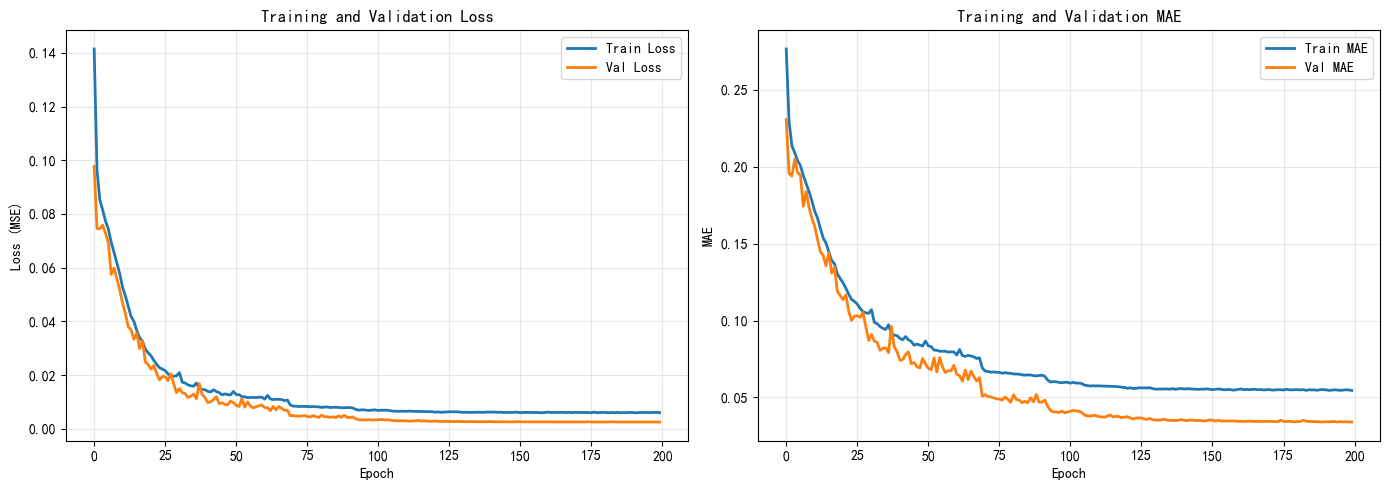

训练历史图已保存至: ./models/lstm_training_history.png


In [28]:
# ==================== 使用示例 ====================
if __name__ == "__main__":
    # 生成模拟数据
    np.random.seed(42)
    
    # 创建并训练模型
    trainer = LSTMTrainerPyTorch(
        seq_len=7,
        n_features=15,
        hidden_dim=128,
        num_layers=2,
        bidirectional=True,
        dropout=0.1,
        learning_rate=0.001
    )
    
    # 训练
    trainer.fit(
        X_train, y_train,
        validation_split=0.1,
        epochs=200,
        batch_size=64,
        verbose=1
    )
    
    # 评估
    print("\n在测试集上评估:")
    metrics = trainer.evaluate(X_test, y_test)
    
    # 保存模型
    trainer.model_save()
    
    #绘制训练历史 
    trainer.plot_training_history()